In [3]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
import gensim
import gensim.corpora as corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

c:\Users\ohgenenyore\OneDrive\Desktop\PythonProjects\AI Engineering\NLP\nlp_env\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Latent Dirichlet Allocation (LDA) for Topic Modelling

In [4]:
news_data = pd.read_csv('news_articles.csv')

articles = pd.DataFrame(news_data['content'])

In [5]:
#convert to lowercase
articles['lowercase'] = articles['content'].apply(lambda x: x.lower())

#remove stopwords
en_stopwords = stopwords.words('english')
articles['no_stopwords'] = articles['lowercase'].apply(lambda x: " ".join([word for word in x.split() if word not in en_stopwords]))

#remove punctuations
articles['no_punct'] = articles['no_stopwords'].apply(lambda x: re.sub(r"[^\w\s]", "", x))

#tokenize
articles['tokenized'] = articles['no_punct'].apply(lambda x: word_tokenize(x))

# stem text
stemmer = PorterStemmer()
articles['stemmed_articles'] = articles['tokenized'].apply(lambda x:[stemmer.stem(token) for token in x])

articles.head()

,content,lowercase,no_stopwords,no_punct,tokenized,stemmed_articles
0,"Dr. Frank Sacks, a professor of nutrition at H...","dr. frank sacks, a professor of nutrition at h...","dr. frank sacks, professor nutrition harvard, ...",dr frank sacks professor nutrition harvard lik...,"[dr, frank, sacks, professor, nutrition, harva...","[dr, frank, sack, professor, nutrit, harvard, ..."
1,South Carolina’s win over Duke was not only ...,south carolina’s win over duke was not only ...,south carolina’s win duke surprise fans. postg...,south carolinas win duke surprise fans postgam...,"[south, carolinas, win, duke, surprise, fans, ...","[south, carolina, win, duke, surpris, fan, pos..."
2,(Want to get this briefing by email? Here’s th...,(want to get this briefing by email? here’s th...,(want get briefing email? here’s .) good eveni...,want get briefing email heres good evening he...,"[want, get, briefing, email, heres, good, even...","[want, get, brief, email, here, good, even, he..."
3,"BANJUL, Gambia — A week after he was inaugu...","banjul, gambia — a week after he was inaugu...","banjul, gambia — week inaugurated another coun...",banjul gambia week inaugurated another countr...,"[banjul, gambia, week, inaugurated, another, c...","[banjul, gambia, week, inaugur, anoth, countri..."
4,The biggest book of the summer isn’t a blockbu...,the biggest book of the summer isn’t a blockbu...,biggest book summer isn’t blockbuster thriller...,biggest book summer isnt blockbuster thriller ...,"[biggest, book, summer, isnt, blockbuster, thr...","[biggest, book, summer, isnt, blockbust, thril..."


In [6]:
dictionary = corpora.Dictionary(articles['stemmed_articles'])
doc_term = [dictionary.doc2bow(text) for text in articles['stemmed_articles']]
print(doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 2), (15, 1), (16, 1), (17, 2), (18, 1), (19, 1), (20, 3), (21, 3), (22, 1), (23, 3), (24, 2), (25, 4), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 2), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 2), (49, 2), (50, 1), (51, 2), (52, 2), (53, 1), (54, 1), (55, 2), (56, 1), (57, 2), (58, 6), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 4), (65, 2), (66, 1), (67, 1), (68, 2), (69, 1), (70, 1), (71, 1), (72, 1), (73, 5), (74, 4), (75, 1), (76, 1), (77, 1), (78, 2), (79, 2), (80, 1), (81, 2), (82, 2), (83, 1), (84, 1), (85, 1), (86, 4), (87, 2), (88, 1), (89, 1), (90, 3), (91, 1), (92, 3), (93, 1), (94, 1), (95, 2), (96, 3), (97, 6), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 2), (108, 5), (109, 1), (110, 2)

In [7]:
#create lda model
lda_model = gensim.models.LdaModel(corpus=doc_term, id2word=dictionary, num_topics=2)
lda_model.print_topics(num_topics=2, num_words=5)

[(0,
  '0.020*"mr" + 0.016*"said" + 0.007*"trump" + 0.004*"would" + 0.004*"year"'),
 (1, '0.010*"said" + 0.010*"mr" + 0.004*"would" + 0.004*"state" + 0.004*"it"')]

LATENT SEMANTIC ANALYSIS (LSA)

In [8]:
lsa_model = LsiModel(corpus=doc_term, id2word=dictionary, num_topics=2)
lsa_model.print_topics(num_topics=2, num_words=5)

[(0, '0.599*"mr" + 0.423*"said" + 0.182*"trump" + 0.127*"state" + 0.119*"it"'),
 (1,
  '-0.555*"mr" + -0.322*"trump" + 0.275*"said" + 0.213*"saudi" + 0.149*"weight"')]

COHERENCE SCORE

In [9]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for i_of_num_topics in range(min_topics, max_topics+1):
    model = LsiModel(corpus=doc_term, id2word=dictionary, num_topics=i_of_num_topics, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles['stemmed_articles'], dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())


<BarContainer object of 10 artists>

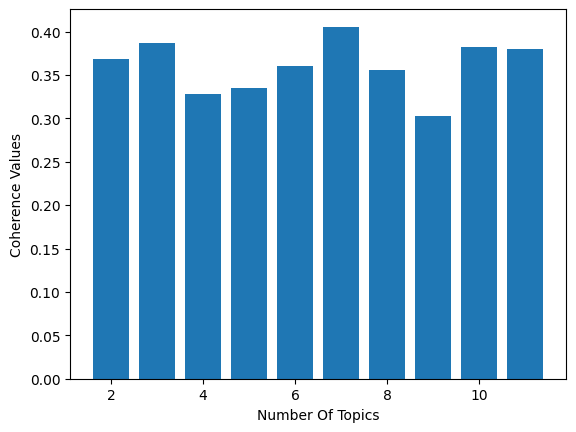

In [14]:
x = range(min_topics, max_topics+1)
y = coherence_values
plt.xlabel("Number Of Topics")
plt.ylabel("Coherence Values")
plt.bar(x, y)

In [17]:
final_num_topics = 7
lsa_model_final = LsiModel(corpus=doc_term, id2word=dictionary, num_topics=final_num_topics)
print(lsa_model_final.print_topics(num_topics=final_num_topics, num_words=5))

[(0, '0.599*"mr" + 0.423*"said" + 0.182*"trump" + 0.127*"state" + 0.119*"it"'), (1, '-0.555*"mr" + -0.322*"trump" + 0.275*"said" + 0.213*"saudi" + 0.149*"weight"'), (2, '-0.471*"saudi" + -0.271*"taliban" + 0.224*"weight" + -0.199*"afghanistan" + -0.193*"arabia"'), (3, '-0.412*"weight" + -0.286*"dr" + -0.231*"diet" + -0.223*"mr" + -0.195*"saudi"'), (4, '0.278*"state" + 0.214*"said" + -0.202*"show" + -0.180*"it" + -0.171*"saudi"'), (5, '-0.586*"trump" + 0.289*"mr" + -0.143*"support" + -0.116*"america" + 0.116*"polic"'), (6, '0.278*"state" + -0.243*"said" + -0.194*"polic" + 0.179*"show" + 0.177*"unit"')]
